# Notebook 02 — TinyCNN Baseline

**არქიტექტურა #1: მინიმალური CNN (1 conv layer)**

მიზანი: ვაჩვენოთ რომ ძალიან პატარა model-ი ვერ აღწევს FER2013-ზე კარგ შედეგს — **underfitting demonstration**.

**ექსპერიმენტები:**
1. Run A — SGD, lr=0.001 (პატარა learning rate → ძალიან ნელი convergence)
2. Run B — Adam, lr=0.001 (default Adam, საფუძველი)
3. Run C — Adam, lr=0.01 (დიდი lr → შესაძლო instability)

**Forward/backward sanity checks** ჩატარდება ტრენინგამდე.


In [1]:
# Drive mount + project setup
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

import os
PROJECT_DIR = '/content/drive/MyDrive/ML_davaleba_4'
os.chdir(PROJECT_DIR)
print(f"Working in: {os.getcwd()}")

Mounted at /content/drive
Working in: /content/drive/MyDrive/ML_davaleba_4


In [2]:
# პაკეტების instalacia (თუ ჯერ არ არის)
!pip install -q wandb seaborn

In [3]:
# Imports
import sys
sys.path.insert(0, f'{PROJECT_DIR}/src')

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import wandb

from utils import (
    load_fer2013, get_dataloaders, count_parameters,
    sanity_check_forward, sanity_check_overfit_batch,
    train_model, evaluate, plot_training_curves,
    get_predictions, plot_confusion_matrix, print_classification_report,
    set_seed,
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
PyTorch: 2.11.0+cu128
GPU: Tesla T4


## WandB ავთენთიფიკაცია

WandB API key ჩაიწერება Colab Secrets-ში — უსაფრთხო შენახვა (Notebook → Secrets → Add: WANDB_API_KEY).

In [4]:
# WandB login
# პირველი ვცდილობთ Colab Secrets-დან წამოღებას, თუ არ აღმოჩნდა — ხელით ჩასმისთვის variable-ი
try:
    from google.colab import userdata
    WANDB_API_KEY = userdata.get('WANDB_API_KEY')
except Exception:
    WANDB_API_KEY = "API_KEY"

wandb.login(key=WANDB_API_KEY)
PROJECT = "ml_davaleba_4"

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: zberi23 (zberi23_ml) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## Data Loading

In [5]:
# preprocessed numpy arrays-ის ჩატვირთვა
X_train, y_train, X_val, y_val, X_test, y_test = load_fer2013(
    f'{PROJECT_DIR}/data/fer2013_processed.npz'
)
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# DataLoaders
BATCH_SIZE = 64
train_loader, val_loader, test_loader = get_dataloaders(
    X_train, y_train, X_val, y_val, X_test, y_test,
    batch_size=BATCH_SIZE, num_workers=2
)
print(f"Batches — train: {len(train_loader)}, val: {len(val_loader)}, test: {len(test_loader)}")

Train: (28709, 48, 48), Val: (3589, 48, 48), Test: (3589, 48, 48)
Batches — train: 449, val: 57, test: 57


## TinyCNN — Architecture #1

მარტივი 1-conv ქსელი — გამიზნულია იმისთვის, რომ აჩვენოს რა ხდება, როცა model-ის capacity დაბალია.

**სტრუქტურა:**
- Conv2d(1 → 8, 3x3, padding=1)
- ReLU
- MaxPool(2)  → (8, 24, 24)
- Flatten → 4608
- Linear → 7

**Trainable params: ~32K**


In [6]:
class TinyCNN(nn.Module):
    """მინიმალური 1-conv CNN — underfitting baseline."""
    def __init__(self, num_classes=7):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.fc = nn.Linear(8 * 24 * 24, num_classes)

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = self.pool(x)
        x = x.flatten(1)
        return self.fc(x)


set_seed(42)
model = TinyCNN().to(device)
print(model)
print(f"\nTrainable parameters: {count_parameters(model):,}")

TinyCNN(
  (conv1): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc): Linear(in_features=4608, out_features=7, bias=True)
)

Trainable parameters: 32,343


## Sanity Checks

ორი check ტრენინგამდე:
1. **Forward pass loss** — უნდა იყოს ≈ log(7) = 1.9459 (uniform random output-სთვის)
2. **Single batch overfit** — model-ს უნდა შეეძლოს ერთი batch-ის სრულად დასწავლა (capacity check)


In [7]:
# Forward pass check
criterion = nn.CrossEntropyLoss()
_ = sanity_check_forward(model, train_loader, criterion, device)

=== Forward Pass Sanity Check ===
  Batch input shape:  (64, 1, 48, 48)
  Batch output shape: (64, 7)
  Initial loss:       2.0936
  Expected (random):  1.9459  = log(7)
  Diff:               0.1477
  Trainable params:   32,343


In [8]:
# Single batch overfit check
set_seed(42)
sanity_model = TinyCNN().to(device)
sanity_opt = optim.Adam(sanity_model.parameters(), lr=1e-3)
_ = sanity_check_overfit_batch(sanity_model, train_loader, sanity_opt, criterion, device, num_steps=200)

=== Overfit Single Batch Sanity Check (200 steps) ===
  Step    0 | loss 2.0936 | acc 0.0000
  Step   20 | loss 1.1432 | acc 0.6719
  Step   40 | loss 0.6455 | acc 0.8438
  Step   60 | loss 0.2918 | acc 1.0000
  Step   80 | loss 0.1238 | acc 1.0000
  Step  100 | loss 0.0613 | acc 1.0000
  Step  120 | loss 0.0362 | acc 1.0000
  Step  140 | loss 0.0240 | acc 1.0000
  Step  160 | loss 0.0171 | acc 1.0000
  Step  180 | loss 0.0128 | acc 1.0000
  Step  199 | loss 0.0101 | acc 1.0000
  Final batch accuracy: 1.0000
  Model can overfit a single batch - capacity OK


## Run A — SGD, lr=0.001

ჰიპოთეზა: SGD ასეთი პატარა learning rate-ით ძალიან ნელა convergence-ს იქნება, შესაძლოა ბოლომდე ვერ მიაღწიოს კარგ accuracy-ს.

wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Epoch   1/15 | train_loss 1.7669 acc 0.2783 | val_loss 1.7193 acc 0.3221 | grad 2.920 | lr 1.00e-03
Epoch   2/15 | train_loss 1.7033 acc 0.3233 | val_loss 1.6702 acc 0.3625 | grad 3.082 | lr 1.00e-03
Epoch   3/15 | train_loss 1.6725 acc 0.3463 | val_loss 1.6514 acc 0.3642 | grad 3.069 | lr 1.00e-03
Epoch   4/15 | train_loss 1.6566 acc 0.3544 | val_loss 1.6411 acc 0.3670 | grad 2.959 | lr 1.00e-03
Epoch   5/15 | train_loss 1.6438 acc 0.3607 | val_loss 1.6415 acc 0.3711 | grad 2.769 | lr 1.00e-03
Epoch   6/15 | train_loss 1.6327 acc 0.3652 | val_loss 1.6283 acc 0.3717 | grad 2.569 | lr 1.00e-03
Epoch   7/15 | train_loss 1.6217 acc 0.3719 | val_loss 1.6161 acc 0.3803 | grad 2.494 | lr 1.00e-03
Epoch   8/15 | train_loss 1.6124 acc 0.3787 | val_loss 1.6173 acc 0.3792 | grad 2.449 | lr 1.00e-03
Epoch   9/15 | train_loss 1.6057 acc 0.3801 | val_loss 1.6179 acc 0.3823 | grad 2.405 | lr 1.00e-03
Epoch  10/15 | train_loss 1.5982 acc 0.3862 | val_loss 1.6042 acc 0.3770 | grad 2.362 | lr 1.00e-03


best_val_acc,▁
epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
grad_norm,▇██▇▅▃▃▂▂▂▁▂▁▁▁
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_acc,▁▃▅▅▅▆▆▆▇▇▇▇▇██
train_loss,█▆▅▄▄▄▃▃▃▂▂▂▂▁▁
val_acc,▁▅▅▅▅▅▆▆▆▆▇▇▇█▇
val_loss,█▆▅▄▄▄▃▃▃▂▂▂▂▁▁
best_val_acc,0.39955
epoch,15
grad_norm,2.3502


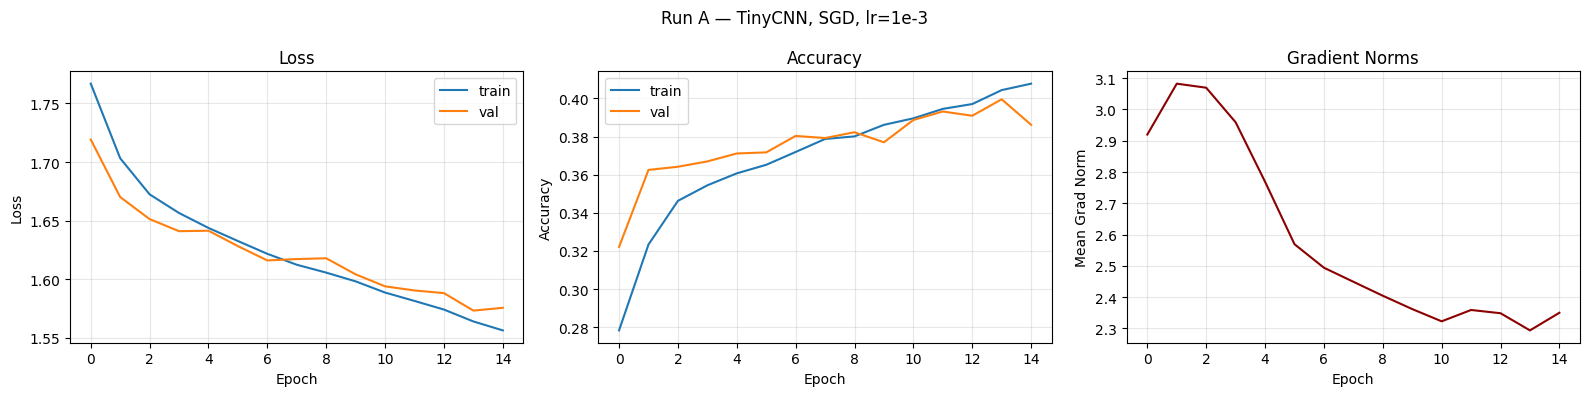

Best val acc: 0.3996


In [9]:
# Run A — SGD, lr=1e-3
set_seed(42)
model_a = TinyCNN().to(device)
optimizer_a = optim.SGD(model_a.parameters(), lr=1e-3, momentum=0.9)

config_a = {
    'architecture': 'TinyCNN',
    'num_params': count_parameters(model_a),
    'optimizer': 'SGD',
    'lr': 1e-3,
    'momentum': 0.9,
    'batch_size': BATCH_SIZE,
    'num_epochs': 15,
}

history_a, best_acc_a = train_model(
    model_a, train_loader, val_loader, optimizer_a, criterion, device,
    num_epochs=15, run_name='02_tinycnn_sgd_lr1e-3',
    project=PROJECT, config=config_a,
    save_path=f'{PROJECT_DIR}/models/02_tinycnn_sgd.pt'
)
wandb.finish()
plot_training_curves(history_a, title="Run A — TinyCNN, SGD, lr=1e-3")
print(f"Best val acc: {best_acc_a:.4f}")

## Run B — Adam, lr=0.001

Default Adam — უფრო სწრაფი convergence-ი მოსალოდნელია.

Epoch   1/15 | train_loss 1.7139 acc 0.3171 | val_loss 1.6243 acc 0.3761 | grad 2.227 | lr 1.00e-03
Epoch   2/15 | train_loss 1.6022 acc 0.3810 | val_loss 1.5767 acc 0.3920 | grad 1.583 | lr 1.00e-03
Epoch   3/15 | train_loss 1.5498 acc 0.4085 | val_loss 1.5343 acc 0.4146 | grad 1.447 | lr 1.00e-03
Epoch   4/15 | train_loss 1.5126 acc 0.4260 | val_loss 1.5210 acc 0.4213 | grad 1.507 | lr 1.00e-03
Epoch   5/15 | train_loss 1.4867 acc 0.4369 | val_loss 1.5212 acc 0.4196 | grad 1.488 | lr 1.00e-03
Epoch   6/15 | train_loss 1.4598 acc 0.4473 | val_loss 1.5058 acc 0.4257 | grad 1.534 | lr 1.00e-03
Epoch   7/15 | train_loss 1.4386 acc 0.4578 | val_loss 1.4923 acc 0.4349 | grad 1.551 | lr 1.00e-03
Epoch   8/15 | train_loss 1.4181 acc 0.4653 | val_loss 1.4891 acc 0.4344 | grad 1.643 | lr 1.00e-03
Epoch   9/15 | train_loss 1.3993 acc 0.4758 | val_loss 1.4888 acc 0.4305 | grad 1.670 | lr 1.00e-03
Epoch  10/15 | train_loss 1.3812 acc 0.4834 | val_loss 1.4737 acc 0.4422 | grad 1.696 | lr 1.00e-03


best_val_acc,▁
epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
grad_norm,█▂▁▂▁▂▂▃▃▃▄▅▅▅▆
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_acc,▁▃▄▅▅▆▆▆▇▇▇▇███
train_loss,█▆▅▅▄▄▃▃▃▂▂▂▁▁▁
val_acc,▁▃▅▅▅▆▇▇▆▇█▇███
val_loss,█▆▄▃▃▃▂▂▂▁▁▁▁▁▁
best_val_acc,0.44776
epoch,15
grad_norm,2.03873


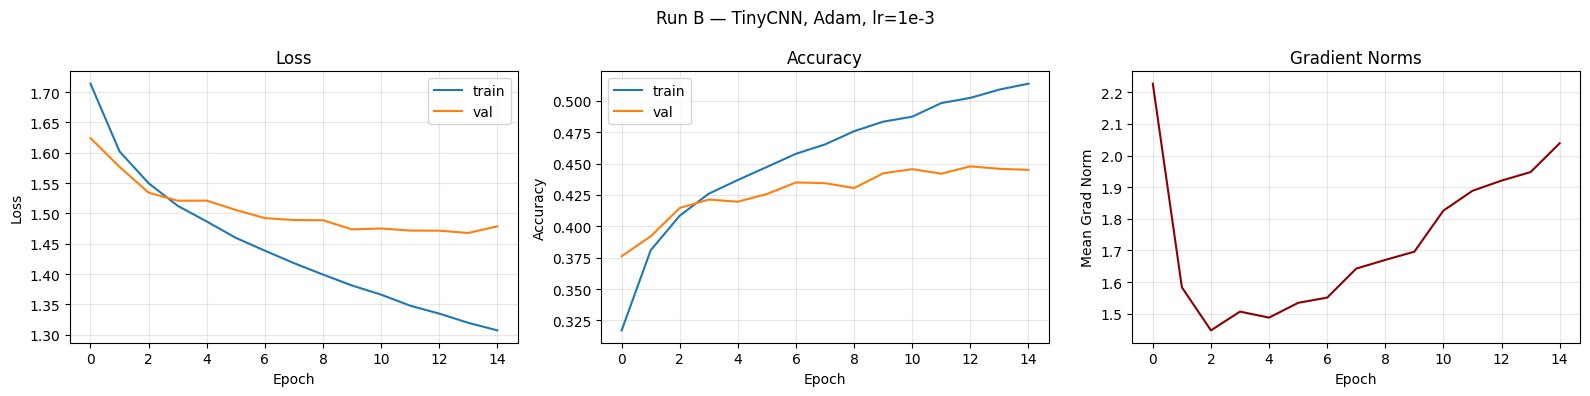

Best val acc: 0.4478


In [10]:
# Run B — Adam, lr=1e-3
set_seed(42)
model_b = TinyCNN().to(device)
optimizer_b = optim.Adam(model_b.parameters(), lr=1e-3)

config_b = {
    'architecture': 'TinyCNN',
    'num_params': count_parameters(model_b),
    'optimizer': 'Adam',
    'lr': 1e-3,
    'batch_size': BATCH_SIZE,
    'num_epochs': 15,
}

history_b, best_acc_b = train_model(
    model_b, train_loader, val_loader, optimizer_b, criterion, device,
    num_epochs=15, run_name='02_tinycnn_adam_lr1e-3',
    project=PROJECT, config=config_b,
    save_path=f'{PROJECT_DIR}/models/02_tinycnn_adam.pt'
)
wandb.finish()
plot_training_curves(history_b, title="Run B — TinyCNN, Adam, lr=1e-3")
print(f"Best val acc: {best_acc_b:.4f}")

## Run C — Adam, lr=0.01

დიდი learning rate Adam-ისთვის — შესაძლოა instability ან divergence.

Epoch   1/15 | train_loss 1.7967 acc 0.3058 | val_loss 1.6586 acc 0.3447 | grad 1.220 | lr 1.00e-02
Epoch   2/15 | train_loss 1.5987 acc 0.3821 | val_loss 1.5893 acc 0.3787 | grad 1.417 | lr 1.00e-02
Epoch   3/15 | train_loss 1.5422 acc 0.4080 | val_loss 1.5621 acc 0.4099 | grad 1.390 | lr 1.00e-02
Epoch   4/15 | train_loss 1.5171 acc 0.4215 | val_loss 1.5844 acc 0.3912 | grad 1.495 | lr 1.00e-02
Epoch   5/15 | train_loss 1.4990 acc 0.4301 | val_loss 1.6033 acc 0.4018 | grad 1.577 | lr 1.00e-02
Epoch   6/15 | train_loss 1.4811 acc 0.4355 | val_loss 1.6093 acc 0.3831 | grad 1.555 | lr 1.00e-02
Epoch   7/15 | train_loss 1.4718 acc 0.4399 | val_loss 1.6207 acc 0.3929 | grad 1.621 | lr 1.00e-02
Epoch   8/15 | train_loss 1.4669 acc 0.4427 | val_loss 1.6099 acc 0.3959 | grad 1.727 | lr 1.00e-02
Epoch   9/15 | train_loss 1.4552 acc 0.4457 | val_loss 1.6454 acc 0.3711 | grad 1.777 | lr 1.00e-02
Epoch  10/15 | train_loss 1.4490 acc 0.4481 | val_loss 1.5980 acc 0.3957 | grad 1.765 | lr 1.00e-02


best_val_acc,▁
epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
grad_norm,▁▂▂▃▄▄▄▅▅▅▆▆█▇█
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_acc,▁▄▆▆▇▇▇▇▇▇█████
train_loss,█▄▃▃▂▂▂▂▂▁▁▁▁▁▁
val_acc,▁▅█▆▇▅▆▇▄▆▇▇▅▇▇
val_loss,█▃▁▃▄▄▅▄▇▄▄▆▇▅▄
best_val_acc,0.40986
epoch,15
grad_norm,2.13981


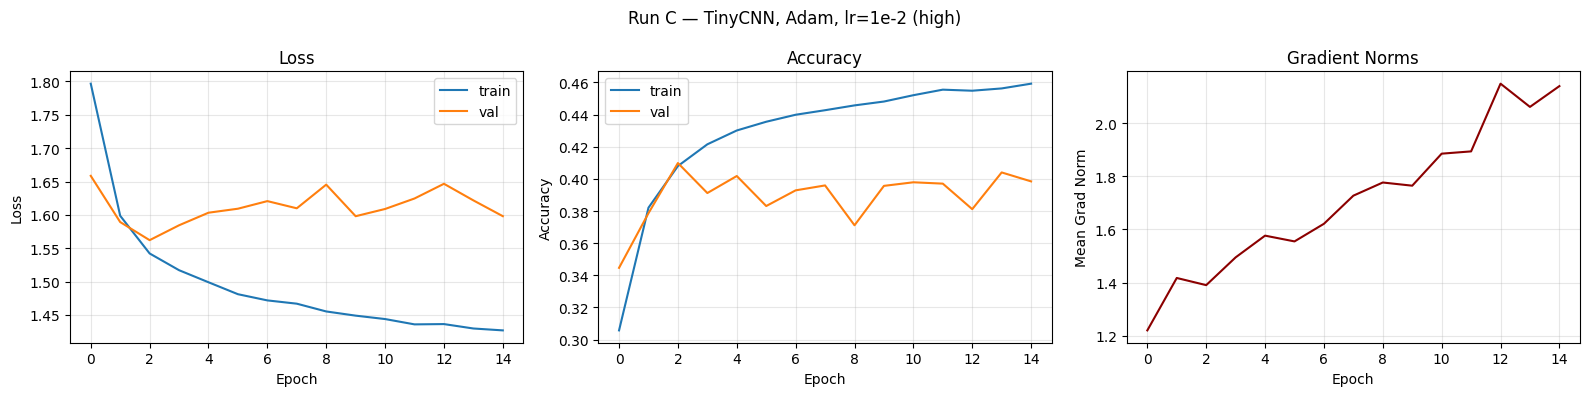

Best val acc: 0.4099


In [11]:
# Run C — Adam, lr=1e-2 (too high)
set_seed(42)
model_c = TinyCNN().to(device)
optimizer_c = optim.Adam(model_c.parameters(), lr=1e-2)

config_c = {
    'architecture': 'TinyCNN',
    'num_params': count_parameters(model_c),
    'optimizer': 'Adam',
    'lr': 1e-2,
    'batch_size': BATCH_SIZE,
    'num_epochs': 15,
}

history_c, best_acc_c = train_model(
    model_c, train_loader, val_loader, optimizer_c, criterion, device,
    num_epochs=15, run_name='02_tinycnn_adam_lr1e-2',
    project=PROJECT, config=config_c
)
wandb.finish()
plot_training_curves(history_c, title="Run C — TinyCNN, Adam, lr=1e-2 (high)")
print(f"Best val acc: {best_acc_c:.4f}")

## Runs შედარება

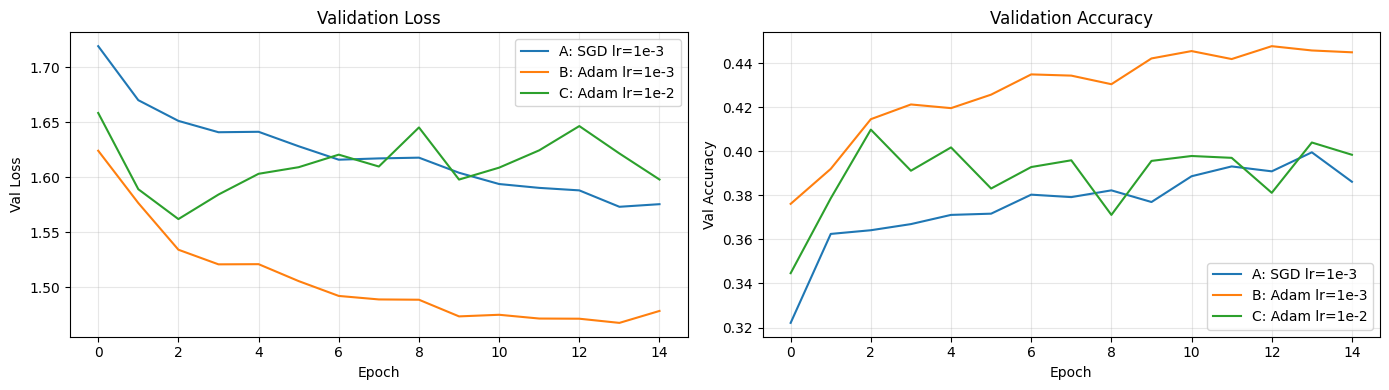


Final val accuracy comparison:
  Run A (SGD lr=1e-3):   0.3996
  Run B (Adam lr=1e-3):  0.4478
  Run C (Adam lr=1e-2):  0.4099


In [12]:
# სამივე run-ის val accuracy ერთად
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history_a['val_loss'], label='A: SGD lr=1e-3')
axes[0].plot(history_b['val_loss'], label='B: Adam lr=1e-3')
axes[0].plot(history_c['val_loss'], label='C: Adam lr=1e-2')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Val Loss')
axes[0].set_title('Validation Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history_a['val_acc'], label='A: SGD lr=1e-3')
axes[1].plot(history_b['val_acc'], label='B: Adam lr=1e-3')
axes[1].plot(history_c['val_acc'], label='C: Adam lr=1e-2')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val Accuracy')
axes[1].set_title('Validation Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

print(f"\nFinal val accuracy comparison:")
print(f"  Run A (SGD lr=1e-3):   {best_acc_a:.4f}")
print(f"  Run B (Adam lr=1e-3):  {best_acc_b:.4f}")
print(f"  Run C (Adam lr=1e-2):  {best_acc_c:.4f}")

## Best Run Evaluation

Test set-ზე საუკეთესო run-ის შეფასება + confusion matrix + per-class metrics.

Test loss: 1.4635
Test accuracy: 0.4522


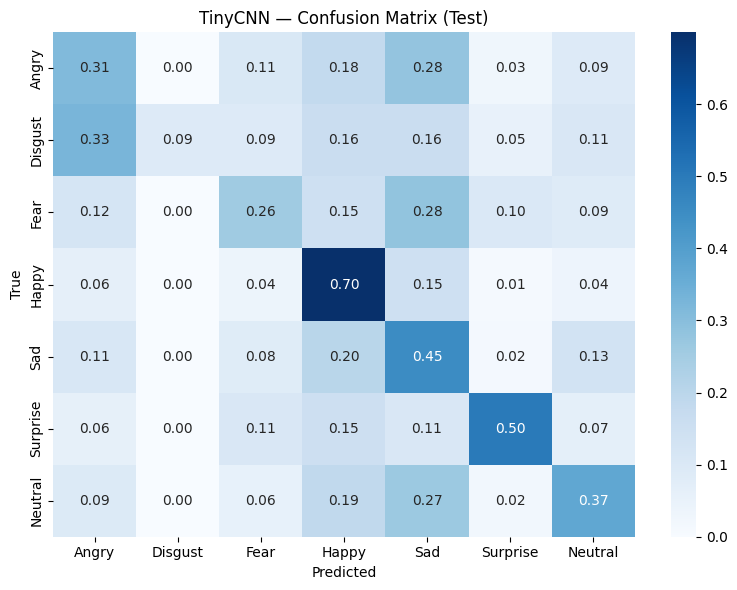

              precision    recall  f1-score   support

       Angry     0.3476    0.3136    0.3298       491
     Disgust     0.8333    0.0909    0.1639        55
        Fear     0.3827    0.2595    0.3093       528
       Happy     0.5637    0.6997    0.6244       879
         Sad     0.2976    0.4529    0.3591       594
    Surprise     0.6635    0.5024    0.5718       416
     Neutral     0.4958    0.3738    0.4262       626

    accuracy                         0.4522      3589
   macro avg     0.5120    0.3847    0.3978      3589
weighted avg     0.4673    0.4522    0.4461      3589



In [13]:
# Load best model (Run B usually best for tiny networks)
best_model = TinyCNN().to(device)
best_model.load_state_dict(torch.load(f'{PROJECT_DIR}/models/02_tinycnn_adam.pt'))

test_loss, test_acc = evaluate(best_model, test_loader, criterion, device)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

# Predictions + confusion matrix
preds, labels = get_predictions(best_model, test_loader, device)
_ = plot_confusion_matrix(preds, labels, title="TinyCNN — Confusion Matrix (Test)")
print_classification_report(preds, labels)

## ანალიზი

**შედეგები:**
- Run A (SGD lr=1e-3): val 39.96% — ძაან ნელი
- Run B (Adam lr=1e-3): val 44.78%, **test 45.22%** — საუკეთესო
- Run C (Adam lr=1e-2): val 40.99% — lr-ი მაგარი დიდი, val_loss oscillates

**რა მოხდა:**
- 32K params 7-კლასიანი FER-ისთვის ძაან ცოტაა, model-ი ვერ ისწავლის ბევრს — underfitting
- Train 51%, val 45% — gap პატარაა (~7%), რაც ნიშნავს რომ overfit-ი არ არის, უბრალოდ capacity-ი არ ყოფნის
- Adam > SGD ცხადია — სწრაფი convergence
- High lr (Run C) ცუდია — instability

**per-class:**
- Happy 0.62 F1, Surprise 0.57 — large + distinctive
- Disgust 0.16 F1 — recall 0.09 (model-ი თითქმის ვერ ცნობს), მხოლოდ 1.5%-ია data-ში
- Sad over-predicted — model-ი გაურკვევლობისას sad-ს ირჩევს

**დასკვნა:** capacity-ი უნდა გავზარდოთ — მეტი conv layers, BatchNorm, regularization.

შემდეგი: **03_small_cnn.ipynb**